# Threshold analysis
February 26, 2024

Can we create a way to threshold the PTR values and create a movie of the the deconvolved gene profiles.

The Goal: Identify an easy way to characterize a gene's cell cycling chromatin. Perhaps a movie or a large set of these genes will give us a good idea on how quantify/simplify these measures.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.config import load_yl_rg1_vst_config
from cc_src.chromatin_model import ChromatinModel

config = load_yl_rg1_vst_config(1)
chromatin_model = ChromatinModel(config)
gene_name = 'CLB2'
chromatin_model.load_mnase_gene(gene_name)


Loading MNase reads for YPR119W/CLB2...Done.


In [3]:
chromatin_model.create_deconvolution_bins()

Unflattened the input data is of shape: (16, 16, 50)
The size of our input data, G is: (16, 800)


In [4]:
chromatin_model.deconvolve()

Deconvolving with gamma=0.006, gamma_prime=0
Deconvolved in : 00:01:27.43
The fitting norm is 5.85, the smoothing norm is: 10.77


In [5]:
from src.model import Model
ge_model = Model(config, gene_name)
ge_model.deconvolve_find_optimal_gamma()

In [6]:
chromatin_model.compute_ptr()

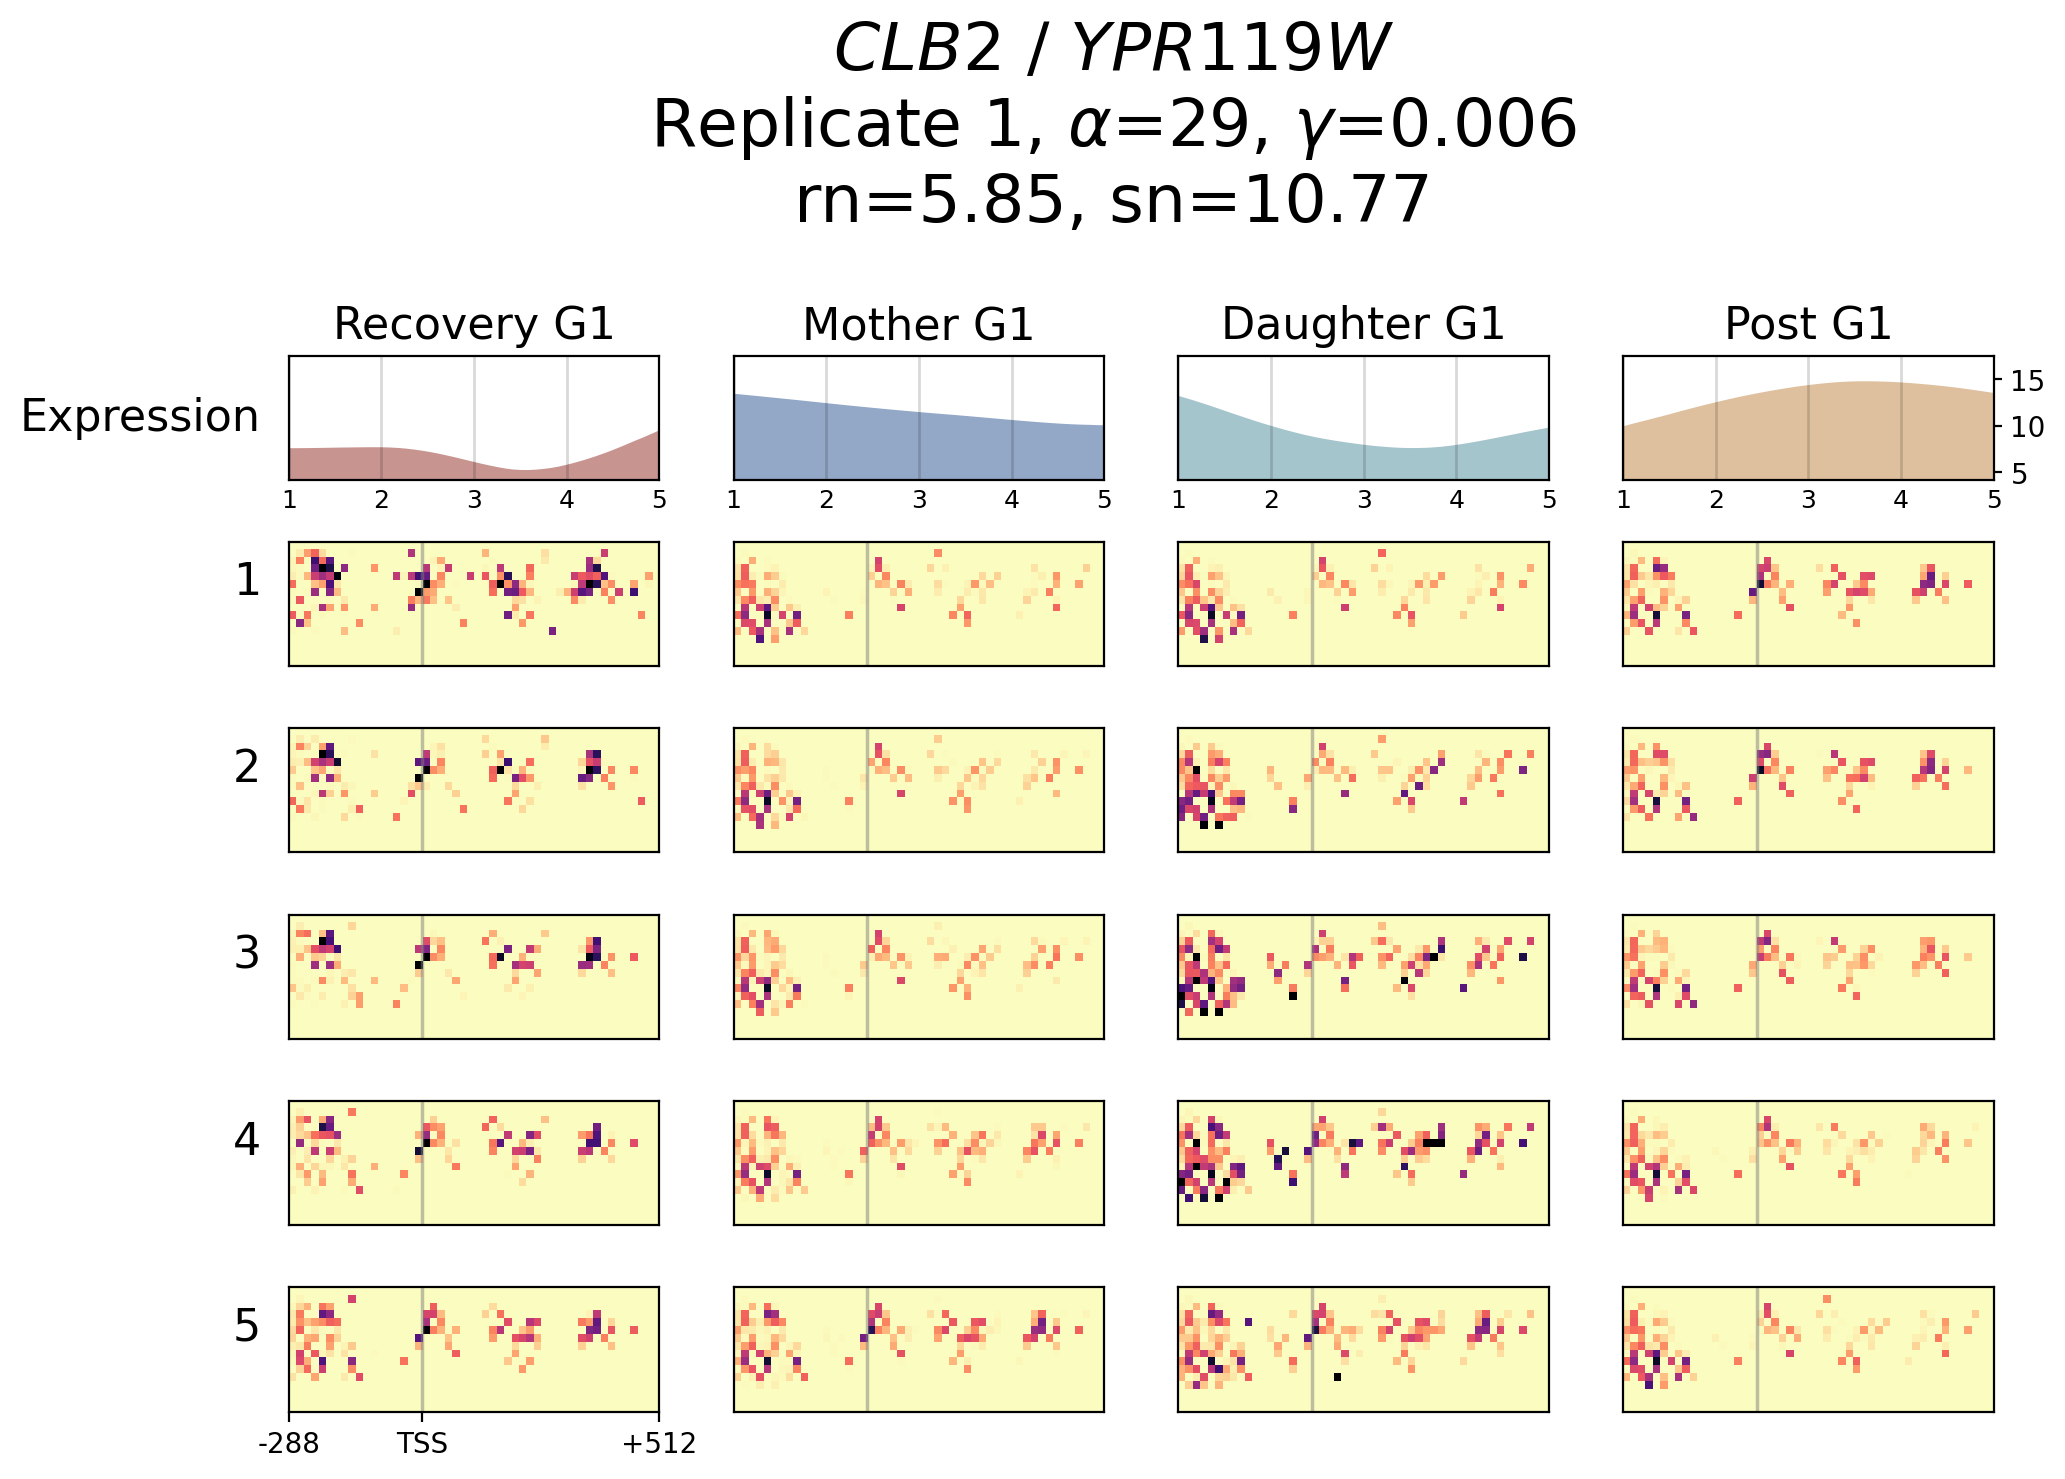

In [7]:
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge_model)

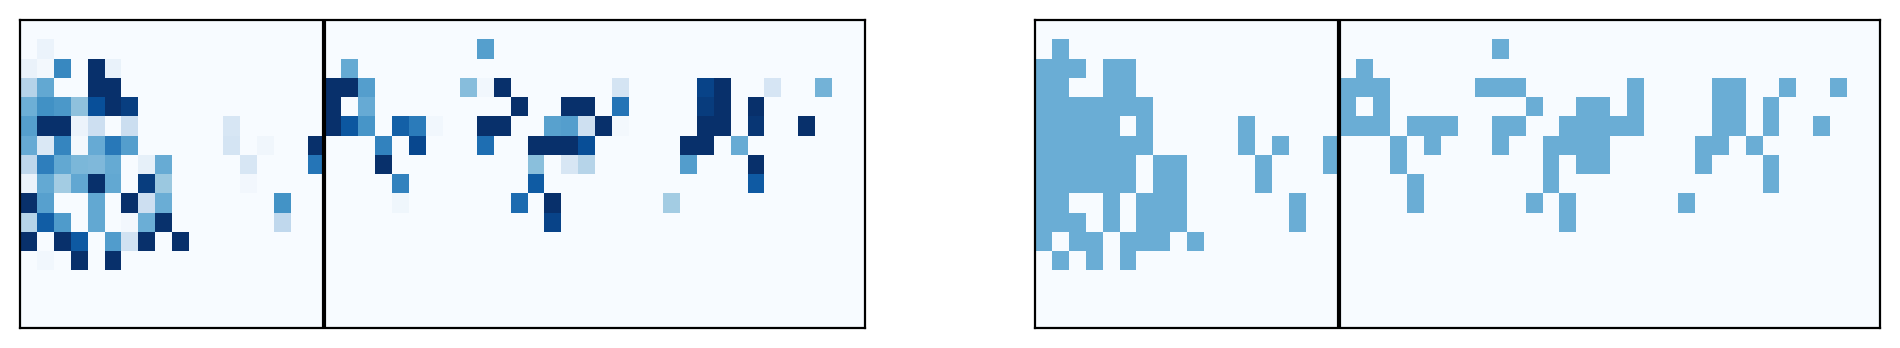

In [39]:

threshold = 1e-3

ptr_img = chromatin_model.f_ptrs.reshape(chromatin_model.image_shape)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 2))

def plot_img(ax0, ptr_img):
    ax0.imshow(ptr_img, vmax=2, vmin=0, origin='lower', cmap='Blues', extent=chromatin_model.bin_extents,
               aspect='auto')
    ax0.axvline(chromatin_model.computed_plus_one, c='black')
    ax0.set_xticks([])
    ax0.set_yticks([])
    
plot_img(ax0, ptr_img)

mask = (ptr_img > threshold)#*2.
plot_img(ax1, mask)

In [43]:
f_images = chromatin_model.get_f_images()
f_images.shape

(227, 16, 50)

In [56]:
from src.heatmap_animator import PTRHeatmapAnimator

animator = PTRHeatmapAnimator(f_images, chromatin_model)

In [137]:
animator.create_animation('output/test.gif')

Creating directory: tmp/frames...Directory exists. Skipping.


In [138]:
from IPython.display import Image
import time

gif_path = 'output/test.gif'
gif_url = f"{gif_path}?{time.time()}" # bypass cached image
Image(url=gif_url) # display image
